In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN = "no-pretrained"  # "no-pretrained"

PROPOSED = {
    "Classification": Path("proposed-method-curve/OOD-classification"),
    "Classification + Pretrained": Path("proposed-method-curve/OOD-classification+pretrained"),
    "Reconstruction": Path("proposed-method-curve/OOD-reconstruction"),
    "Reconstruction + Pretrained": Path("proposed-method-curve/OOD-reconstruction+pretrained"),
}

if RUN == "pretrained":
    proposed_names = ["Classification + Pretrained", "Reconstruction + Pretrained"]
else:
    proposed_names = ["Classification", "Reconstruction"]

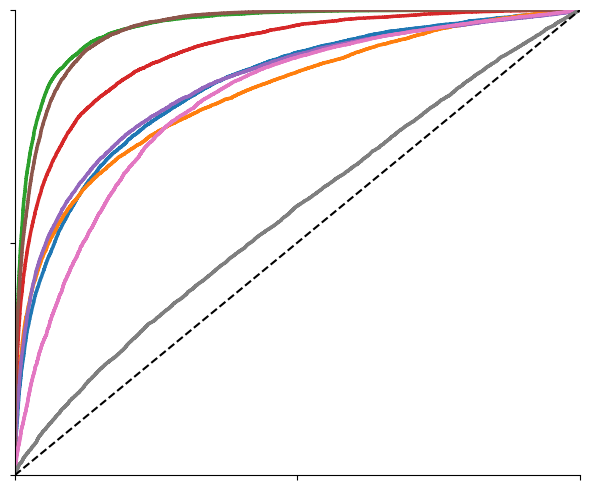

In [44]:
roc = pd.read_csv("outputs/cifar10_curve_data/cifar10_baseline_roc_points.csv")
roc = roc[roc["run"] == RUN]

plt.figure(figsize=(6, 5))

for method, df in roc.groupby("method_display"):
    plt.plot(df["x_fpr"], df["y_tpr"], label=method, linewidth=2.5)

for name in proposed_names:
    df = pd.read_csv(PROPOSED[name] / "roc_curve.csv")
    plt.plot(df["fpr"], df["tpr"], label=name, linewidth=2.5)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess", linewidth=1.5)

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title(f"ROC Curve - CIFAR-10 ({RUN})")
plt.xticks([0.0, 0.5, 1.0], ["", "", ""])
plt.yticks([0.0, 0.5, 1.0], ["", "", ""])
plt.xlim(0, 1)
plt.ylim(0, 1)
ax = plt.gca()
ax.spines["top"].set_visible(False) # 윗쪽 spine 제거
ax.spines["right"].set_visible(False) # 오른쪽 spine 제거


# plt.legend()

plt.tight_layout()
plt.savefig(
    "out.svg",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True,
)

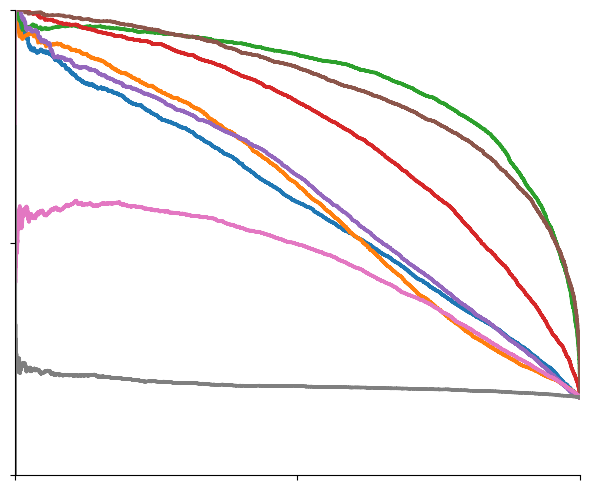

In [45]:
pr = pd.read_csv("outputs/cifar10_curve_data/cifar10_baseline_pr_in_points.csv")
pr = pr[pr["run"] == RUN]

plt.figure(figsize=(6, 5))

for method, df in pr.groupby("method_display"):
    plt.plot(df["x_recall"], df["y_precision"], label=method, linewidth=2.5)

for name in proposed_names:
    df = pd.read_csv(PROPOSED[name] / "pr_curve_aupr_in.csv")
    plt.plot(df["recall"], df["precision"], label=name, linewidth=2.5)

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title(f"ROC Curve - CIFAR-10 ({RUN})")
plt.xticks([0.0, 0.5, 1.0], ["", "", ""])
plt.yticks([0.0, 0.5, 1.0], ["", "", ""])
plt.xlim(0, 1)
plt.ylim(0, 1)
ax = plt.gca()
ax.spines["top"].set_visible(False) # 윗쪽 spine 제거
ax.spines["right"].set_visible(False) # 오른쪽 spine 제거


# plt.legend()

plt.tight_layout()
plt.savefig(
    "out.svg",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True,
)